# Text Preprocessing & Vector Space Model

Notebook Tugas 2 mengolah hasil crawling Tugas 1 — 200 artikel `detik.com` dari `Output/berita.csv` — menjadi korpus bersih dan representasi TF-IDF yang siap dipakai pemodelan data mining. Alurnya meliputi: membaca data, eksplorasi awal, analisis kualitas teks & normalisasi karakter, pelestarian nama diri & entitas khusus, standarisasi kata tidak baku, ekstraksi kata unik, representasi TF-IDF, dan reduksi dimensi dengan PCA.

## Workflow Outline
Empat fase besar pemrosesan teks:
1. **Data & Exploration** — Reading the Data, Initial Exploration, Distribution & Length.
2. **Cleaning & Language** — Text Quality (Format Artifacts), Character Normalization, Token Census (Single & Two Letter).
3. **Meaning Preservation** — Preserving Proper Nouns, Composite Tokens (`3x3`, `U-18`, mata uang), Slang Standardization, Final Corpus.
4. **Representation & Reduction** — Unique Word Extraction, TF-IDF Representation, Dimensionality Reduction with PCA.

# Phase 1 — Data & Exploration

## Reading the Data
Data dibaca langsung dari berkas CSV hasil crawl. Pemeriksaan di sini ringkas menjadi titik berangkat karena fokus notebook ini ada di tingkat isi teks.

In [1]:
import os
import re
import unicodedata
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

csv_path = "Output/berita.csv" if os.path.exists("Output/berita.csv") else "../output/berita.csv"
df = pd.read_csv(csv_path)[["ID", "Isi Berita", "Label"]]
print(df.shape)
display(df.head(5))

(199, 3)


,ID,Isi Berita,Label
0,1,"Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026. Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan dilakukan.\nYudha Saputera dkk gagal meraih kemenangan dalam tiga pertandingan Grup A. Indonesia kalah telak dari Jepang 53-98, kemudian takluk 48-102 dari Korea Selatan, dan kembali menelan kekalahan saat menghadapi Arab Saudi dengan skor 89-100.\nHasil tersebut membuat Indonesia finis di posisi keempat Grup A dengan tiga poin dari tiga kekalahan. Tim Merah Putih pun harus mengakhiri kiprahnya lebih awal. Singleton secara terbuka mengakui hasil tersebut tidak sesuai dengan standar yang ditetapkan untuk tim nasional.\n""Kami menilai hasil ini sebagai kegagalan. Kami yakin masih banyak potensi yang bisa kami tunjukkan, namun kami tidak mendapatkan proses adaptasi yang cukup cepat selama berada di Jepang,"" kata pelatih yang karib disapa Dave ini dikutip dari laman federasi.\nSingleton menegaskan timnya tidak ingin mencari alasan atas hasil buruk tersebut. Menurutnya, Indonesia membutuhkan lebih banyak pengalaman bertanding dan waktu kebersamaan, terutama dalam persiapan menghadapi Asian Games.\n""Kami tidak mencari-cari alasan. Itu poin utamanya. Jika harus menjawab berdasarkan fakta, kami sebenarnya membutuhkan lebih banyak pengalaman bertanding dan waktu kebersamaan, terutama bagi tim Asian Games. Kami baru benar-benar bangkit dan menunjukkan kemampuan terbaik kami pada pertandingan ketiga,"" jelasnya.\nMeski gagal meraih kemenangan, Singleton menilai para pemain tetap menunjukkan perjuangan hingga pertandingan terakhir. ""Hal yang ingin saya tekankan adalah tim kami tetap tampil dan berjuang hingga akhir. Kami ingin masyarakat Indonesia tahu bahwa kami tidak akan pernah menyerah,"" ujarnya.\n| Pelatih Timnas basket putra Indonesia David Singleton Foto: Dok. Perbasi | \nNamun, Singleton mengakui penampilan Indonesia belum mencerminkan kemampuan sebenarnya.\n""Sayangnya, kami tidak bisa menunjukkan jati diri kami yang sesungguhnya hingga pertandingan terakhir melawan Arab Saudi. Ini bukanlah standar yang ingin kami tetapkan di level tim nasional,"" tegas Singleton.\nKegagalan di Asian Games 2026 pun menjadi bahan evaluasi besar bagi seluruh elemen tim. Evaluasi tidak hanya menyasar pelatih dan pemain, tetapi juga staf pendukung, aspek organisasi, hingga penjadwalan.\n""Kami harus mengevaluasi segalanya. Federasi memiliki harapan agar kami meraih kemenangan dan tampil lebih baik. Oleh karena itu, mulai dari pelatih, pemain, staf pendukung, hingga aspek organisasi dan penjadwalan, semuanya akan dievaluasi dan diperbaiki,"" tuturnya.\nSingleton juga menilai pembenahan tidak boleh berhenti di level tim senior. Pengembangan pemain dan pelatih dari level akar rumput dinilai penting untuk menyiapkan generasi berikutnya.\n""Kami sebenarnya tidak jauh dari pencapaian hasil yang lebih baik, namun kami harus bergerak dalam hal pengembangan dan peningkatan, tidak hanya di level senior, tetapi juga di tingkat akar rumput (baik bagi pemain maupun pelatih), demi generasi mendatang.""\n""Kami akan mencari berbagai cara untuk melakukan perbaikan, baik pada masa persiapan maupun selama kompetisi berlangsung,"" tegas Singleton.\n(mcy/krs)",sport
1,2,"Perbasi merilis roster Timnas Basket 3x3 Putri Indonesia yang akan berlaga di Asian Games 2026. Empat pemain dipilih untuk membawa Merah Putih dalam ajang yang digelar di Jepang tersebut.\nKeempat pemain itu adalah Jesslyne Jaya Wiyanto, Thasya Hery Saputera, Erlina Christiana, dan Diva Intan Nur Fadillah. Mereka akan berjuang di bawah asuhan Deny Sartika.\nDeny optimistis dengan komposisi yang dimiliki Timnas Basket 3x3 Putri Indonesia. Ia menilai skuadnya memiliki perpaduan pemain big dan small yang dapat menjadi modal menghadapi persaingan di fase grup.\n""Komposisi ini secara size ada dua pemain big dan dua small. Nana dan Thasya dengan pengalamannya bisa mengangkat tim dan nge-lead teman-

## Completeness Check
Kelengkapan baris dicek sekaligus: jumlah baris, nilai kosong, baris ganda, dan keseimbangan label.

In [2]:
checks = pd.DataFrame({
    "pemeriksaan": [
        "jumlah baris",
        "nilai kosong",
        "baris ganda",
        "urutan id",
        "jumlah per label"
    ],
    "hasil": [
        len(df),
        df.isna().sum().sum(),
        df.duplicated(subset=["Isi Berita"]).sum(),
        "lengkap 1-" + str(len(df)) if list(df["ID"]) == list(range(1, len(df) + 1)) else "sesuai",
        f"sport: {(df['Label']=='sport').sum()}; finance: {(df['Label']=='finance').sum()}"
    ]
})
display(checks)

,pemeriksaan,hasil
0,jumlah baris,199
1,nilai kosong,0
2,baris ganda,0
3,urutan id,lengkap 1-199
4,jumlah per label,sport: 100; finance: 99


## Length & Distribution
Panjang teks per label diamati sebelum pembersihan supaya anomali (dokumen nyaris kosong, label timpang, ekor panjang) terlihat lebih dulu.

panjang_karakter               jumlah_kata             
                     min  median   max         min median   max
Label                                                          
finance              284  2342.0  7498          40  314.0   934
sport                866  1661.0  7554         133  246.0  1057

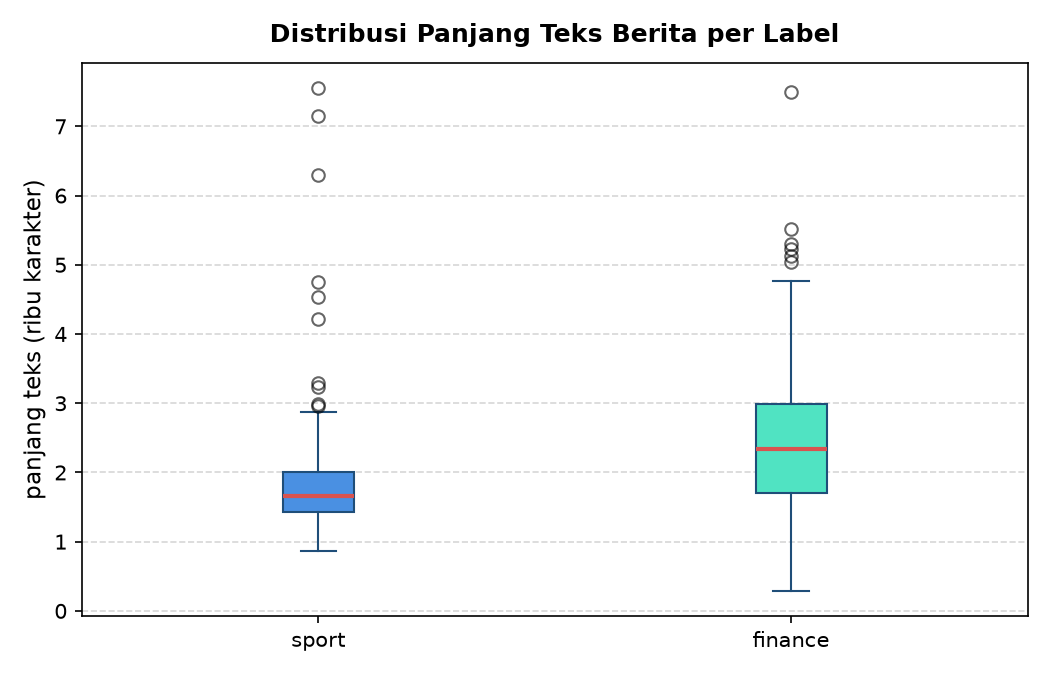

In [3]:
stats = df.assign(
    panjang_karakter=df["Isi Berita"].str.len(),
    jumlah_kata=df["Isi Berita"].str.split().str.len()
).groupby("Label")[["panjang_karakter", "jumlah_kata"]].agg(["min", "median", "max"])

display(stats)

# Boxplot distribusi panjang karakter
plt.figure(figsize=(7, 4.5))
data_box = [
    df[df["Label"] == "sport"]["Isi Berita"].str.len() / 1000,
    df[df["Label"] == "finance"]["Isi Berita"].str.len() / 1000
]
box = plt.boxplot(data_box, tick_labels=["sport", "finance"], patch_artist=True,
                  boxprops=dict(facecolor="#4A90E2", color="#1f4e79"),
                  medianprops=dict(color="#d9534f", linewidth=2))
box['boxes'][1].set_facecolor("#50E3C2")
plt.ylabel("panjang teks (ribu karakter)", fontsize=11)
plt.title("Distribusi Panjang Teks Berita per Label", fontsize=12, fontweight='bold', pad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Phase 2 — Cleaning & Language

## Text Quality: Format Artifacts
Pengecekan pertama di tingkat teks: karakter di luar ASCII (aksen, emoji, tanda hubung non-breaking) dilacak per artikel.

In [4]:
def chars_outside_ascii(text):
    return sorted({c for c in str(text) if ord(c) > 127})

rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["Isi Berita"])
    if extra:
        rows.append({"id": r["ID"], "label": r["Label"], "karakter": " ".join(extra)})

display(pd.DataFrame(rows).head(6))

,id,label,karakter
0,5,sport,️ 🎙 🐐 🚨
1,19,sport,😭 😳 🚨
2,20,sport,ó — 🇦 🇷
3,37,sport,— 💚 🖤
4,51,sport,ö
5,77,sport,í


## Character Normalization
Aksen dinormalisasi ke huruf dasar menggunakan `unicodedata.normalize("NFD")` (agar nama tetap terbaca, misal `é` $\rightarrow$ `e`), serta tanda hubung non-breaking disamakan dengan tanda hubung biasa.

In [5]:
def normalize_letters(text):
    if not isinstance(text, str):
        return ""
    decomposed = unicodedata.normalize("NFD", text)
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    return text.replace("\u2011", "-").replace("\u2010", "-").replace("\u2013", "-").replace("\u2014", "-")

print("Normalisasi karakter selesai.")

Normalisasi karakter selesai.


## Artifact Counts & Token Census
Korpus dicacah dalam kondisi teks sesudah operasi naif untuk mengidentifikasi token satu huruf dan token dua huruf beserta konteks aslinya.

In [6]:
def naive_tokens(text):
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()

all_naive = [w for doc in df["Isi Berita"] for w in naive_tokens(str(doc))]
naive_counts = Counter(all_naive)
single_counts = {w: n for w, n in naive_counts.items() if len(w) == 1}
double_counts = {w: n for w, n in naive_counts.items() if len(w) == 2}

total_naive = len(all_naive)
df_naive_summary = pd.DataFrame({
    "metrik": ["token total", "kata unik", "token satu huruf", "token dua huruf"],
    "jumlah": [total_naive, len(naive_counts), sum(single_counts.values()), sum(double_counts.values())],
    "proporsi": [
        "100%",
        f"{100 * len(naive_counts) / total_naive:.2f}%",
        f"{100 * sum(single_counts.values()) / total_naive:.2f}%",
        f"{100 * sum(double_counts.values()) / total_naive:.2f}%"
    ]
})
display(df_naive_summary)

# Pengecekan konteks token 1 huruf (pecahan komposit seperti 3x3, U-18, dsb.)
def get_context(texts, word, window=25):
    pattern = re.compile(rf"(?<![A-Za-z]){re.escape(word)}(?![A-Za-z])", re.IGNORECASE)
    for text in texts:
        m = pattern.search(text)
        if m:
            start = max(0, m.start() - window)
            end = min(len(text), m.end() + window)
            return text[start:end].replace("\n", " ")
    return "-"

df_single_top = pd.DataFrame([
    {"huruf": w, "jumlah": n} for w, n in sorted(single_counts.items(), key=lambda x: -x[1])[:8]
])
df_single_context = pd.DataFrame([
    {"huruf": w, "konteks": get_context(df["Isi Berita"], w)}
    for w in df_single_top["huruf"]
])
display(df_single_context)

,metrik,jumlah,proporsi
0,token total,60070,100%
1,kata unik,7314,12.18%
2,token satu huruf,193,0.32%
3,token dua huruf,2558,4.26%


,huruf,konteks
0,a,m tiga pertandingan Grup A. Indonesia kalah telak d
1,d,"onesia tergabung di Pool D bersama Singapura, Thail"
2,u,"sebut telah masuk timnas U-19, empat pemain ke timn"
3,i,tu dipastikan absen saat I Neroverdi menghadapi Mon
4,p,anya sekali naik podium (P2) dalam 61 seri terakhir
5,x,is roster Timnas Basket 3x3 Putri Indonesia yang ak
6,g,"i posisi keempat kelas T1G, kendaraan beserta perle"
7,s,rgentina. Lionel Scaloni's squad list for the upcom


## Two-Letter Token Census
Membedah token dua huruf: memisahkan kata fungsi bahasa Indonesia (seperti `di`, `ke`, `ia`, `ya`) dari singkatan/satuan/kode yang bukan kata bermakna (seperti `rp`, `bi`, `kg`, `pt`).

In [7]:
stopwords_2huruf = {"di", "ke", "ia", "ya", "ah", "eh", "oh", "ha", "si", "se"}
df_double_top = pd.DataFrame([
    {"token": w, "jumlah": n, "stopword": w in stopwords_2huruf, "konteks": get_context(df["Isi Berita"], w)}
    for w, n in sorted(double_counts.items(), key=lambda x: -x[1])[:15]
])
display(df_double_top)

,token,jumlah,stopword,konteks
0,di,1140,True,membuat Indonesia finis di posisi keempat Grup A de
1,ke,290,True,a Indonesia gagal melaju ke perempatfinal Asian Game
2,rp,234,False,er masing-masing senilai Rp 250 ribu. Selamat untuk
3,ia,98,True,ket 3x3 Putri Indonesia. Ia menilai skuadnya memilik
4,vs,70,False,gue mempertemukan Al Ain vs Al Nassr. Pertandingan d
5,pt,67,False,akademi sepakbola milik PT Freeport Indonesia. Papu
6,ya,63,True,"n secara hitung-hitungan ya Korea Selatan,"" jelas De"
7,al,44,False,"Munich, Aston Villa, dan Al Duhail. | Baca juga: Sia"
8,as,33,False,"a Ruiz yang dikutip dari AS. ""Saya cukup beruntung b"
9,kg,33,False,ya akan turun di kelas 65kg dan Asian Games di Aichi


# Phase 3 — Meaning Preservation

## Protecting Composite Tokens
Komposit bermakna — URL, lambang mata uang, kata berangka alfanumerik (`3x3`, `U-18`, `76ers`, `GA-604`), dan angka Romawi — diblokir sebagai satu kesatuan sebelum angka dan simbol dibuang, agar tidak tersisa pecahan seperti `x` dari `3x3`.

In [8]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(r"\b(?=[A-Za-z]*\d)[A-Za-z0-9]+(?:-[A-Za-z0-9]+)*\b")
currency_pattern = re.compile(r"\b(?:rp|us\$|usd)\b|\b(?:rp|us\$)\s*[\d.,]+", re.IGNORECASE)
roman_pattern = re.compile(r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v[x]{0,2}|xi{0,3})\b", re.IGNORECASE)

n_url = sum(len(url_pattern.findall(t)) for t in df["Isi Berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["Isi Berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["Isi Berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["Isi Berita"])

df_protected_stats = pd.DataFrame({
    "jenis": ["URL", "komposit alfanumerik & angka", "lambang mata uang", "angka Romawi"],
    "kemunculan": [n_url, n_alnum, n_curr, n_roman],
    "contoh": ["pic.twitter.com/...", "3x3, U-18, 76ers, GA-604", "Rp, US$, Rp 1.000.000", "IV, VIII, XI"]
})
display(df_protected_stats)

,jenis,kemunculan,contoh
0,URL,6,pic.twitter.com/...
1,komposit alfanumerik & angka,3287,"3x3, U-18, 76ers, GA-604"
2,lambang mata uang,263,"Rp, US$, Rp 1.000.000"
3,angka Romawi,51,"IV, VIII, XI"


## Slang Standardization (Pembakuan Kata Tidak Baku)
Membakukan kata-kata tidak baku, singkatan, dan bahasa gaul ke bentuk baku bahasa Indonesia dengan sistem pengecualian (*guarded replace*) agar istilah khusus olahraga (seperti `dunk`, `slam`, `fans`, `pass`) atau singkatan nama tidak salah diubah.

In [9]:
# Kamus pembakuan kata
kamus_baku = {
    'tdk': 'tidak', 'tak': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'enggak': 'tidak',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'dlm': 'dalam', 'kpd': 'kepada',
    'dr': 'dari', 'bkn': 'bukan', 'krn': 'karena', 'bgt': 'sangat', 'banget': 'sangat',
    'jd': 'jadi', 'bnyk': 'banyak', 'sdh': 'sudah', 'udah': 'sudah', 'udh': 'sudah',
    'blm': 'belum', 'tp': 'tapi', 'tsb': 'tersebut', 'org': 'orang', 'sy': 'saya',
    'km': 'kamu', 'kl': 'kalau', 'klo': 'kalau', 'kalo': 'kalau', 'hrs': 'harus',
    'bs': 'bisa', 'adlh': 'adalah', 'dpt': 'dapat', 'thn': 'tahun', 'bln': 'bulan',
    'hr': 'hari', 'rb': 'ribu', 'jt': 'juta', 'm': 'miliar', 't': 'triliun',
    'rp': 'rupiah', 'nih': 'ini', 'tuh': 'itu', 'aja': 'saja', 'cuman': 'cuma',
    'sampe': 'sampai', 'gmn': 'bagaimana', 'bgmn': 'bagaimana', 'knp': 'kenapa',
    'bener': 'benar', 'skrg': 'sekarang', 'gitu': 'begitu', 'gini': 'begini',
    'kayak': 'seperti', 'bgitu': 'begitu', 'bgtu': 'begitu', 'donk': 'dong',
    'lu': 'kamu', 'gue': 'saya', 'gw': 'saya', 'lo': 'kamu', 'ok': 'oke',
    'acc': 'setuju', 'min': 'admin', 'max': 'maksimal', 'prof': 'profesor',
    'org2': 'orang-orang', 'gara2': 'gara-gara', 'bener2': 'benar-benar',
    'untk': 'untuk', 'dapet': 'dapat', 'ngomong': 'berbicara', 'pake': 'pakai'
}

# Istilah olahraga & nama yang dilindungi dari perubahan slang
excluded_slang = {"dunk", "slam", "minta", "fans", "pala", "masukin", "pass", "usa", "mbg", "sma", "smp", "bird", "bca"}

def protect(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")

def guarded_replace(text):
    words = text.split()
    res = []
    for w in words:
        w_lower = w.lower()
        if w_lower in excluded_slang:
            res.append(w)
        elif w_lower in kamus_baku:
            res.append(kamus_baku[w_lower])
        else:
            res.append(w)
    return " ".join(res)

def clean_full(text):
    text = normalize_letters(text)
    text = protect(text)
    text = guarded_replace(text)
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text).lower()
    words = [w for w in text.split() if len(w) >= 2 and (len(w) > 2 or w in stopwords_2huruf)]
    return " ".join(words)

df["Isi_Berita_Final"] = df["Isi Berita"].apply(clean_full)

print("Contoh Sebelum Pembersihan:")
print(df["Isi Berita"].iloc[0][:180] + "...")
print("\nContoh Sesudah Pembersihan & Pembakuan:")
print(df["Isi_Berita_Final"].iloc[0][:180] + "...")

Contoh Sebelum Pembersihan:
Timnas basket putra Indonesia gagal melaju ke perempatfinal Asian Games 2026. Pelatih David Singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh a...

Contoh Sesudah Pembersihan & Pembakuan:
timnas basket putra indonesia gagal melaju ke perempatfinal asian games pelatih david singleton menyebut hasil tersebut sebagai kegagalan dan menegaskan evaluasi menyeluruh akan di...


## Final Corpus
Korpus bersih dirangkum: total token, kosakata per label, dan sisa token dua huruf.

In [10]:
final_docs = [t.split() for t in df["Isi_Berita_Final"]]
all_final_tokens = [w for doc in final_docs for w in doc]
final_counts = Counter(all_final_tokens)
final_unique_count = len(final_counts)
final_token_total = len(all_final_tokens)

df_final_summary = pd.DataFrame({
    "metrik": ["token total", "kata unik", "token dua huruf tersisa", "token per label"],
    "jumlah": [
        f"{final_token_total:,}",
        f"{final_unique_count:,}",
        ", ".join([f"{w}: {final_counts[w]}" for w in sorted(stopwords_2huruf) if w in final_counts]),
        f"sport: {sum(len(t.split()) for t in df[df['Label']=='sport']['Isi_Berita_Final']):,}, finance: {sum(len(t.split()) for t in df[df['Label']=='finance']['Isi_Berita_Final']):,}"
    ]
})
display(df_final_summary)

,metrik,jumlah
0,token total,"58,895"
1,kata unik,"7,166"
2,token dua huruf tersisa,"ah: 1, di: 1140, ia: 98, ke: 290, oh: 3, se: 2, si: 10, ya: 63"
3,token per label,"sport: 27,243, finance: 31,652"


# Phase 4 — Representation & Reduction

## Unique Word Extraction & Vocabulary by Label
Kosakata unik masing-masing label dihitung untuk melihat kekhasannya (kata khusus olahraga vs keuangan vs irisan kedua label).

In [11]:
sport_words = set(w for doc in df[df["Label"] == "sport"]["Isi_Berita_Final"] for w in doc.split())
finance_words = set(w for doc in df[df["Label"] == "finance"]["Isi_Berita_Final"] for w in doc.split())
shared_words = sport_words.intersection(finance_words)

df_vocab_by_label = pd.DataFrame({
    "label": ["sport", "finance", "dipakai kedua label"],
    "kata unik": [len(sport_words), len(finance_words), len(shared_words)]
})
display(df_vocab_by_label)

# 10 kata paling sering muncul di korpus
df_most_frequent = pd.DataFrame([
    {"kata": w, "kemunculan": n} for w, n in final_counts.most_common(20)
])
display(df_most_frequent.head(10))

# Simpan daftar kata unik ke folder Output
df_most_frequent.to_csv("Output/kata_unik.csv", index=False)

,label,kata unik
0,sport,4294
1,finance,4411
2,dipakai kedua label,1539


,kata,kemunculan
0,yang,1251
1,dan,1188
2,di,1140
3,ini,620
4,dengan,589
5,dari,584
6,untuk,528
7,dalam,428
8,itu,422
9,pada,402


## TF-IDF Representation
Korpus akhir diubah ke matriks TF-IDF menggunakan `sklearn.feature_extraction.text.TfidfVectorizer` dengan panjang token minimum 2 karakter.

In [12]:
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")
X = vectorizer.fit_transform(df["Isi_Berita_Final"])
tfidf_features = vectorizer.get_feature_names_out()

df_tfidf_meta = pd.DataFrame({
    "metrik": ["dokumen", "fitur", "entri bukan nol (nnz)"],
    "nilai": [X.shape[0], X.shape[1], X.nnz]
})
display(df_tfidf_meta)

# Simpan matriks TF-IDF ke CSV
os.makedirs("Output", exist_ok=True)
df_tfidf_out = pd.DataFrame(X.toarray(), columns=tfidf_features, index=[f"Dokumen_{i}" for i in df["ID"]])
df_tfidf_out.to_csv("Output/tfidf_berita.csv")

,metrik,nilai
0,dokumen,199
1,fitur,7166
2,entri bukan nol (nnz),32970


## Dimensionality Reduction with PCA
Sebagai penutup pemodelan, matriks TF-IDF diproyeksikan ke dua komponen utama (`PC1`, `PC2`) menggunakan `sklearn.decomposition.PCA` untuk melihat keterpisahan antar label.

,komponen,proporsi varians
0,PC1,0.0351
1,PC2,0.0225
2,jumlah,0.0576


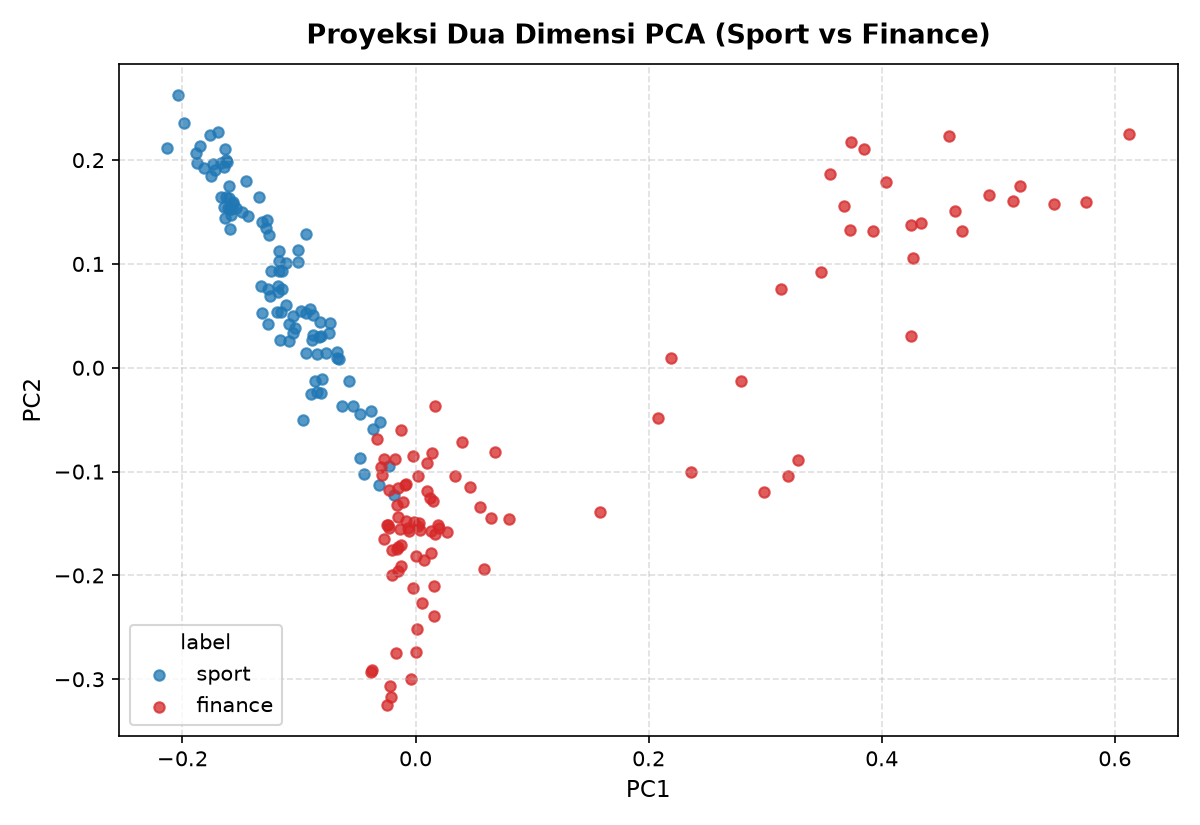

In [13]:
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X.toarray())
evr = pca.explained_variance_ratio_

df_evr = pd.DataFrame({
    "komponen": ["PC1", "PC2", "jumlah"],
    "proporsi varians": [f"{evr[0]:.4f}", f"{evr[1]:.4f}", f"{evr.sum():.4f}"]
})
display(df_evr)

# Visualisasi 2D Scatter Plot
plt.figure(figsize=(8, 5.5))
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    mask = (df["Label"] == label).values
    plt.scatter(Z[mask, 0], Z[mask, 1], s=25, alpha=0.75, label=label, c=color)

plt.xlabel("PC1", fontsize=11)
plt.ylabel("PC2", fontsize=11)
plt.title("Proyeksi Dua Dimensi PCA (Sport vs Finance)", fontsize=13, fontweight='bold', pad=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="label", fontsize=10)
plt.tight_layout()
plt.show()

# Simpan hasil PCA ke CSV
df_pca_save = pd.DataFrame(Z, columns=["PC1", "PC2"])
df_pca_save["ID"] = df["ID"]
df_pca_save["Label"] = df["Label"]
df_pca_save.to_csv("Output/pca_berita.csv", index=False)

## Conclusion
Korpus siap dipakai pemodelan. Ringkasan angka proses:

In [14]:
df_conclusion = pd.DataFrame({
    "metrik": ["dokumen awal", "token bersih", "kata unik", "fitur TF-IDF", "varians dua komponen PCA", "artefak yang disisihkan"],
    "nilai": [
        str(len(df)),
        f"{final_token_total:,}",
        str(final_unique_count),
        str(len(tfidf_features)),
        f"{sum(pca.explained_variance_ratio_)*100:.1f}%",
        f"URL {n_url}, mata uang {n_curr}, komposit {n_alnum}, romawi {n_roman}"
    ]
})
display(df_conclusion)

,metrik,nilai
0,dokumen awal,199
1,token bersih,"58,895"
2,kata unik,7166
3,fitur TF-IDF,7166
4,varians dua komponen PCA,5.8%
5,artefak yang disisihkan,"URL 6, mata uang 263, komposit 3287, romawi 51"
